In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip install -q transformers accelerate sentencepiece scipy

Mounted at /content/drive


In [2]:
from pathlib import Path
import random
import copy
import time
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from sklearn.metrics import (
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# Experiment 3: Longformer Regression
# ============================================================

PROJECT_NAME = "IELTS-Writing-Evals"

TEXT_COL = "essay"
SET_COL = "essay_set"
SCORE_COL = "domain1_score"

METHOD_NAME = "Longformer Regression"
MODEL_NAME = "allenai/longformer-base-4096"

SEED = 42

# ============================================================
# Longformer fine-tuning config
# ============================================================
# Colab T4/P100 safe config:
# Nếu bị OOM, giảm MAX_LENGTH xuống 768 hoặc BATCH_SIZE = 1.
# Nếu GPU khỏe, có thể tăng MAX_LENGTH lên 1536.

MAX_LENGTH = 1024

BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

EPOCHS = 5
PATIENCE = 2

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
MAX_GRAD_NORM = 1.0

USE_AMP = True

# ============================================================
# Output files
# ============================================================

RESULT_FILENAME = "experiment3_longformer_results.csv"
PREDICTION_FILENAME = "experiment3_longformer_predictions.csv"


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Effective batch size:", EFFECTIVE_BATCH_SIZE)

Device: cuda
GPU: Tesla T4
Effective batch size: 16


In [4]:
# ============================================================
# Find project root in Google Drive
# ============================================================

def find_project_root(project_name=PROJECT_NAME):
    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/Colab Notebooks"),
        Path("/content"),
    ]

    for root in search_roots:
        if not root.exists():
            continue

        direct_candidate = root / project_name
        if direct_candidate.exists() and direct_candidate.is_dir():
            return direct_candidate

        matches = list(root.rglob(project_name))
        matches = [p for p in matches if p.is_dir() and p.name == project_name]

        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"Cannot find project folder '{project_name}' in Google Drive. "
        "Please make sure the folder exists in MyDrive."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "dataset" / "asap"
RESULT_DIR = PROJECT_ROOT / "benchmark_results" / "ASAP"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

train_path = DATA_DIR / "asap_train.csv"
val_path = DATA_DIR / "asap_val.csv"
test_path = DATA_DIR / "asap_test.csv"

result_path = RESULT_DIR / RESULT_FILENAME
prediction_path = RESULT_DIR / PREDICTION_FILENAME

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Result dir:", RESULT_DIR)

print("\nTrain path:", train_path)
print("Val path:  ", val_path)
print("Test path: ", test_path)

print("\nResult path:", result_path)
print("Prediction path:", prediction_path)

for path in [train_path, val_path, test_path]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

Project root: /content/drive/MyDrive/ielts/IELTS-Writing-Evals
Data dir: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/dataset/asap
Result dir: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP

Train path: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/dataset/asap/asap_train.csv
Val path:   /content/drive/MyDrive/ielts/IELTS-Writing-Evals/dataset/asap/asap_val.csv
Test path:  /content/drive/MyDrive/ielts/IELTS-Writing-Evals/dataset/asap/asap_test.csv

Result path: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP/experiment3_longformer_results.csv
Prediction path: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP/experiment3_longformer_predictions.csv


In [5]:
# ============================================================
# Load data
# ============================================================

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

required_cols = {TEXT_COL, SET_COL, SCORE_COL}

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{name}.csv missing columns: {missing_cols}")

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

print("\nEssay sets:")
print("Train:", sorted(train_df[SET_COL].unique()))
print("Val:  ", sorted(val_df[SET_COL].unique()))
print("Test: ", sorted(test_df[SET_COL].unique()))

# ============================================================
# Hard leakage check
# ============================================================

if "essay_id" in train_df.columns:
    train_ids = set(train_df["essay_id"])
    val_ids = set(val_df["essay_id"])
    test_ids = set(test_df["essay_id"])

    print("\nID overlap check:")
    print("Train-Val overlap: ", len(train_ids & val_ids))
    print("Train-Test overlap:", len(train_ids & test_ids))
    print("Val-Test overlap:  ", len(val_ids & test_ids))

    print("\nDuplicate check:")
    print("Train duplicated:", train_df["essay_id"].duplicated().sum())
    print("Val duplicated:  ", val_df["essay_id"].duplicated().sum())
    print("Test duplicated: ", test_df["essay_id"].duplicated().sum())

    assert len(train_ids & val_ids) == 0, "Leakage: train and val overlap."
    assert len(train_ids & test_ids) == 0, "Leakage: train and test overlap."
    assert len(val_ids & test_ids) == 0, "Leakage: val and test overlap."

summary = pd.DataFrame({
    "train": train_df[SET_COL].value_counts().sort_index(),
    "val": val_df[SET_COL].value_counts().sort_index(),
    "test": test_df[SET_COL].value_counts().sort_index(),
})

summary["total"] = summary["train"] + summary["val"] + summary["test"]

display(summary)

Train: (9084, 5)
Val:   (1296, 5)
Test:  (2596, 5)

Essay sets:
Train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Val:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Test:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

ID overlap check:
Train-Val overlap:  0
Train-Test overlap: 0
Val-Test overlap:   0

Duplicate check:
Train duplicated: 0
Val duplicated:   0
Test duplicated:  0


,train,val,test,total
essay_set,,,,
1,1248,180,355,1783
2,1260,180,360,1800
3,1208,173,345,1726
4,1239,177,354,1770
5,1263,180,362,1805
6,1261,180,359,1800
7,1098,157,314,1569
8,507,69,147,723


In [6]:
# ============================================================
# Tokenizer
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", MODEL_NAME)
print("Tokenizer model max length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: allenai/longformer-base-4096
Tokenizer model max length: 1000000000000000019884624838656


In [7]:
# ============================================================
# Dataset
# ============================================================

class EssayRegressionDataset(Dataset):
    def __init__(
        self,
        df,
        tokenizer,
        min_score,
        max_score,
        max_length=MAX_LENGTH,
    ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.min_score = float(min_score)
        self.max_score = float(max_score)
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = str(row[TEXT_COL])
        score = float(row[SCORE_COL])

        # Normalize label to [0, 1]
        if self.max_score > self.min_score:
            score_norm = (score - self.min_score) / (self.max_score - self.min_score)
        else:
            score_norm = 0.0

        encoded = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors=None,
        )

        input_ids = encoded["input_ids"]
        attention_mask = encoded["attention_mask"]

        # Longformer needs global attention.
        # CLS token gets global attention.
        global_attention_mask = [0] * len(input_ids)
        global_attention_mask[0] = 1

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "global_attention_mask": torch.tensor(global_attention_mask, dtype=torch.long),
            "score": torch.tensor(score, dtype=torch.float),
            "score_norm": torch.tensor(score_norm, dtype=torch.float),
        }


def create_dataloader(
    df,
    tokenizer,
    min_score,
    max_score,
    batch_size=BATCH_SIZE,
    shuffle=False,
):
    dataset = EssayRegressionDataset(
        df=df,
        tokenizer=tokenizer,
        min_score=min_score,
        max_score=max_score,
        max_length=MAX_LENGTH,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False,
    )

In [8]:
# ============================================================
# Metrics
# ============================================================

def denormalize_predictions(pred_norm, min_score, max_score):
    pred_norm = np.asarray(pred_norm, dtype=float)
    pred_score = pred_norm * (max_score - min_score) + min_score
    return pred_score


def clip_and_round_predictions(y_pred, min_score, max_score):
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, min_score, max_score)
    y_pred = np.rint(y_pred).astype(int)
    return y_pred


def compute_metrics(y_true, y_pred_int):
    y_true = np.asarray(y_true).astype(int)
    y_pred_int = np.asarray(y_pred_int).astype(int)

    qwk = cohen_kappa_score(y_true, y_pred_int, weights="quadratic")
    mae = mean_absolute_error(y_true, y_pred_int)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_int))

    return {
        "qwk": qwk,
        "mae": mae,
        "rmse": rmse,
    }


# ============================================================
# QWK threshold optimization on validation set only
# ============================================================

def apply_thresholds(y_pred_raw, thresholds, score_values):
    """
    Convert continuous prediction to discrete score using thresholds.

    Example:
    score_values = [0, 1, 2, 3]
    thresholds = [0.5, 1.5, 2.5]
    """
    y_pred_raw = np.asarray(y_pred_raw, dtype=float)
    thresholds = np.asarray(thresholds, dtype=float)
    score_values = np.asarray(score_values, dtype=int)

    idx = np.digitize(y_pred_raw, thresholds)
    idx = np.clip(idx, 0, len(score_values) - 1)

    return score_values[idx]


def optimize_qwk_thresholds(y_true, y_pred_raw, min_score, max_score):
    """
    Optimize thresholds on validation predictions only.
    This is allowed because validation set is for model/decision rule selection.
    Test set is never used here.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred_raw = np.asarray(y_pred_raw, dtype=float)

    score_values = np.arange(int(min_score), int(max_score) + 1)

    if len(score_values) <= 1:
        return np.array([]), score_values

    # Initial thresholds: midpoints between consecutive score values
    initial_thresholds = (score_values[:-1] + score_values[1:]) / 2.0

    def objective(thresholds):
        thresholds = np.sort(thresholds)
        y_pred_int = apply_thresholds(y_pred_raw, thresholds, score_values)
        qwk = cohen_kappa_score(y_true, y_pred_int, weights="quadratic")

        if np.isnan(qwk):
            return 1.0

        return -qwk

    result = minimize(
        objective,
        initial_thresholds,
        method="Nelder-Mead",
        options={
            "maxiter": 300,
            "disp": False,
        },
    )

    optimized_thresholds = np.sort(result.x)

    return optimized_thresholds, score_values

In [9]:
# ============================================================
# Model / optimizer / scheduler
# ============================================================

def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        problem_type="regression",
    )

    # Enable gradient checkpointing to reduce memory usage on Colab.
    if hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()

    return model


def get_optimizer_and_scheduler(model, train_loader, epochs):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    num_update_steps_per_epoch = int(
        np.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
    )

    total_training_steps = num_update_steps_per_epoch * epochs
    warmup_steps = int(total_training_steps * WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_training_steps,
    )

    return optimizer, scheduler

In [10]:
# ============================================================
# Train / evaluate helpers
# ============================================================

def train_one_epoch(model, train_loader, optimizer, scheduler, scaler=None):
    model.train()

    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        global_attention_mask = batch["global_attention_mask"].to(device)
        labels = batch["score_norm"].to(device)

        with torch.cuda.amp.autocast(enabled=(USE_AMP and torch.cuda.is_available())):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                global_attention_mask=global_attention_mask,
                labels=labels,
            )

            loss = outputs.loss
            loss = loss / GRADIENT_ACCUMULATION_STEPS

        if scaler is not None and torch.cuda.is_available():
            scaler.scale(loss).backward()
        else:
            loss.backward()

        is_update_step = (
            (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0
            or (step + 1) == len(train_loader)
        )

        if is_update_step:
            if scaler is not None and torch.cuda.is_available():
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS * input_ids.size(0)

    return total_loss / len(train_loader.dataset)


@torch.no_grad()
def evaluate_model(model, dataloader, min_score, max_score):
    model.eval()

    all_true = []
    all_pred_norm = []

    total_loss = 0.0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        global_attention_mask = batch["global_attention_mask"].to(device)
        labels = batch["score_norm"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            global_attention_mask=global_attention_mask,
            labels=labels,
        )

        loss = outputs.loss
        logits = outputs.logits.squeeze(-1)

        total_loss += loss.item() * input_ids.size(0)

        all_true.extend(batch["score"].cpu().numpy().tolist())
        all_pred_norm.extend(logits.detach().cpu().numpy().tolist())

    y_true = np.asarray(all_true).astype(int)

    y_pred_raw = denormalize_predictions(
        all_pred_norm,
        min_score=min_score,
        max_score=max_score,
    )

    y_pred_round = clip_and_round_predictions(
        y_pred_raw,
        min_score=min_score,
        max_score=max_score,
    )

    round_metrics = compute_metrics(y_true, y_pred_round)

    avg_loss = total_loss / len(dataloader.dataset)

    return avg_loss, round_metrics, y_true, y_pred_raw, y_pred_round

In [11]:
# ============================================================
# Train Longformer per essay_set
# ============================================================

results = []
all_predictions = []

essay_sets = sorted(train_df[SET_COL].unique())

start_time = time.time()

for essay_set in essay_sets:
    print(f"\n================ Essay set {essay_set} ================")

    set_seed(SEED + int(essay_set))

    train_set_df = train_df[train_df[SET_COL] == essay_set].copy()
    val_set_df = val_df[val_df[SET_COL] == essay_set].copy()
    test_set_df = test_df[test_df[SET_COL] == essay_set].copy()

    # Score range dùng train + val.
    # Không dùng test labels để tránh leakage.
    train_val_set_df = pd.concat([train_set_df, val_set_df], axis=0)

    min_score = int(train_val_set_df[SCORE_COL].min())
    max_score = int(train_val_set_df[SCORE_COL].max())

    print("Train size:", len(train_set_df))
    print("Val size:  ", len(val_set_df))
    print("Test size: ", len(test_set_df))
    print("Score range used:", min_score, "-", max_score)

    train_loader = create_dataloader(
        df=train_set_df,
        tokenizer=tokenizer,
        min_score=min_score,
        max_score=max_score,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    val_loader = create_dataloader(
        df=val_set_df,
        tokenizer=tokenizer,
        min_score=min_score,
        max_score=max_score,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_loader = create_dataloader(
        df=test_set_df,
        tokenizer=tokenizer,
        min_score=min_score,
        max_score=max_score,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    model = build_model().to(device)

    optimizer, scheduler = get_optimizer_and_scheduler(
        model=model,
        train_loader=train_loader,
        epochs=EPOCHS,
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=(USE_AMP and torch.cuda.is_available())
    )

    best_val_qwk = -999.0
    best_epoch = -1
    best_state_dict = None

    best_val_loss = None
    best_val_metrics_round = None
    best_val_metrics_opt = None
    best_thresholds = None
    best_score_values = None

    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        train_loss = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
        )

        val_loss, val_metrics_round, y_val_true, y_val_raw, y_val_round = evaluate_model(
            model=model,
            dataloader=val_loader,
            min_score=min_score,
            max_score=max_score,
        )

        # Tune QWK thresholds on validation only
        thresholds, score_values = optimize_qwk_thresholds(
            y_true=y_val_true,
            y_pred_raw=y_val_raw,
            min_score=min_score,
            max_score=max_score,
        )

        y_val_opt = apply_thresholds(
            y_pred_raw=y_val_raw,
            thresholds=thresholds,
            score_values=score_values,
        )

        val_metrics_opt = compute_metrics(y_val_true, y_val_opt)

        epoch_time = time.time() - epoch_start

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val QWK round: {val_metrics_round['qwk']:.4f} | "
            f"Val QWK opt: {val_metrics_opt['qwk']:.4f} | "
            f"Val MAE opt: {val_metrics_opt['mae']:.4f} | "
            f"Val RMSE opt: {val_metrics_opt['rmse']:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        # Select checkpoint using optimized validation QWK
        if val_metrics_opt["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics_opt["qwk"]
            best_epoch = epoch

            # Move checkpoint to CPU to save GPU memory
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            best_val_loss = val_loss
            best_val_metrics_round = val_metrics_round
            best_val_metrics_opt = val_metrics_opt
            best_thresholds = thresholds
            best_score_values = score_values

            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    # Load best checkpoint
    model.load_state_dict(best_state_dict)
    model.to(device)

    # Final test evaluation
    test_loss, test_metrics_round, y_test_true, y_test_raw, y_test_round = evaluate_model(
        model=model,
        dataloader=test_loader,
        min_score=min_score,
        max_score=max_score,
    )

    # Apply validation-optimized thresholds to test predictions
    y_test_opt = apply_thresholds(
        y_pred_raw=y_test_raw,
        thresholds=best_thresholds,
        score_values=best_score_values,
    )

    test_metrics_opt = compute_metrics(y_test_true, y_test_opt)

    print(
        f"\nBest epoch: {best_epoch} | "
        f"Test QWK round: {test_metrics_round['qwk']:.4f} | "
        f"Test QWK opt: {test_metrics_opt['qwk']:.4f} | "
        f"Test MAE opt: {test_metrics_opt['mae']:.4f} | "
        f"Test RMSE opt: {test_metrics_opt['rmse']:.4f}"
    )

    results.append({
        "essay_set": essay_set,
        "method": METHOD_NAME,
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "grad_accumulation": GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size": EFFECTIVE_BATCH_SIZE,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "best_epoch": best_epoch,
        "score_min": min_score,
        "score_max": max_score,
        "train_size": len(train_set_df),
        "val_size": len(val_set_df),
        "test_size": len(test_set_df),

        "val_qwk_round": best_val_metrics_round["qwk"],
        "val_mae_round": best_val_metrics_round["mae"],
        "val_rmse_round": best_val_metrics_round["rmse"],

        "val_qwk": best_val_metrics_opt["qwk"],
        "val_mae": best_val_metrics_opt["mae"],
        "val_rmse": best_val_metrics_opt["rmse"],

        "test_qwk_round": test_metrics_round["qwk"],
        "test_mae_round": test_metrics_round["mae"],
        "test_rmse_round": test_metrics_round["rmse"],

        "test_qwk": test_metrics_opt["qwk"],
        "test_mae": test_metrics_opt["mae"],
        "test_rmse": test_metrics_opt["rmse"],
    })

    pred_df = test_set_df.copy()
    pred_df["method"] = METHOD_NAME
    pred_df["model_name"] = MODEL_NAME
    pred_df["prediction_raw"] = y_test_raw
    pred_df["prediction_rounded"] = y_test_round
    pred_df["prediction_thresholded"] = y_test_opt
    pred_df["score_min"] = min_score
    pred_df["score_max"] = max_score
    pred_df["best_epoch"] = best_epoch

    all_predictions.append(pred_df)

    # Clean memory before next essay_set
    del model
    del optimizer
    del scheduler
    del scaler

    torch.cuda.empty_cache()
    gc.collect()

end_time = time.time()

print("\nTotal training time:", round((end_time - start_time) / 60, 2), "minutes")


================ Essay set 1 ================
Train size: 1248
Val size:   180
Test size:  355
Score range used: 2 - 12


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
longformer.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.bias       | MISSING    | 
classifier.out_proj.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
longformer.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.bias       | MISSING    | 
classifier.out_proj.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.1023 | Val Loss: 0.0142 | Val QWK round: 0.7495 | Val QWK opt: 0.8224 | Val MAE opt: 1.9682 | Val RMSE opt: 2.4378 | Time: 333.4s
Epoch 02 | Train Loss: 0.0235 | Val Loss: 0.0112 | Val QWK round: 0.8260 | Val QWK opt: 0.8672 | Val MAE opt: 1.6815 | Val RMSE opt: 2.1710 | Time: 334.4s
Epoch 03 | Train Loss: 0.0185 | Val Loss: 0.0123 | Val QWK round: 0.8255 | Val QWK opt: 0.8679 | Val MAE opt: 1.6561 | Val RMSE opt: 2.2060 | Time: 334.1s
Epoch 04 | Train Loss: 0.0158 | Val Loss: 0.0109 | Val QWK round: 0.8529 | Val QWK opt: 0.8614 | Val MAE opt: 1.7261 | Val RMSE opt: 2.2246 | Time: 333.4s
Epoch 05 | Train Loss: 0.0153 | Val Loss: 0.0097 | Val QWK round: 0.8744 | Val QWK opt: 0.8815 | Val MAE opt: 1.5924 | Val RMSE opt: 2.1115 | Time: 334.1s

Best epoch: 5 | Test QWK round: 0.8692 | Test QWK opt: 0.8677 | Test MAE opt: 1.8185 | Test RMSE opt: 2.3466

================ Essay set 8 ================
Train size: 507
Val size:   69
Test size:  147
Score range used: 10 

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
longformer.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.bias       | MISSING    | 
classifier.out_proj.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.0921 | Val Loss: 0.0063 | Val QWK round: 0.5976 | Val QWK opt: 0.6530 | Val MAE opt: 3.0580 | Val RMSE opt: 3.7008 | Time: 157.8s
Epoch 02 | Train Loss: 0.0167 | Val Loss: 0.0085 | Val QWK round: 0.6089 | Val QWK opt: 0.6534 | Val MAE opt: 3.3768 | Val RMSE opt: 4.2682 | Time: 157.2s
Epoch 03 | Train Loss: 0.0123 | Val Loss: 0.0058 | Val QWK round: 0.6617 | Val QWK opt: 0.7056 | Val MAE opt: 2.8551 | Val RMSE opt: 3.5570 | Time: 157.4s
Epoch 04 | Train Loss: 0.0109 | Val Loss: 0.0066 | Val QWK round: 0.6875 | Val QWK opt: 0.7034 | Val MAE opt: 3.2609 | Val RMSE opt: 3.9691 | Time: 158.0s
Epoch 05 | Train Loss: 0.0108 | Val Loss: 0.0055 | Val QWK round: 0.7025 | Val QWK opt: 0.7404 | Val MAE opt: 2.8551 | Val RMSE opt: 3.5078 | Time: 158.2s

Best epoch: 5 | Test QWK round: 0.7225 | Test QWK opt: 0.7086 | Test MAE opt: 3.2925 | Test RMSE opt: 4.1305

Total training time: 217.28 minutes


In [12]:
# ============================================================
# Save results
# ============================================================

results_df = pd.DataFrame(results)

average_row = {
    "essay_set": "average",
    "method": METHOD_NAME,
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "grad_accumulation": GRADIENT_ACCUMULATION_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "best_epoch": "-",
    "score_min": "-",
    "score_max": "-",
    "train_size": results_df["train_size"].sum(),
    "val_size": results_df["val_size"].sum(),
    "test_size": results_df["test_size"].sum(),

    "val_qwk_round": results_df["val_qwk_round"].mean(),
    "val_mae_round": results_df["val_mae_round"].mean(),
    "val_rmse_round": results_df["val_rmse_round"].mean(),

    "val_qwk": results_df["val_qwk"].mean(),
    "val_mae": results_df["val_mae"].mean(),
    "val_rmse": results_df["val_rmse"].mean(),

    "test_qwk_round": results_df["test_qwk_round"].mean(),
    "test_mae_round": results_df["test_mae_round"].mean(),
    "test_rmse_round": results_df["test_rmse_round"].mean(),

    "test_qwk": results_df["test_qwk"].mean(),
    "test_mae": results_df["test_mae"].mean(),
    "test_rmse": results_df["test_rmse"].mean(),
}

final_results_df = pd.concat(
    [results_df, pd.DataFrame([average_row])],
    axis=0,
    ignore_index=True,
)

predictions_df = pd.concat(all_predictions, axis=0, ignore_index=True)

final_results_df.to_csv(result_path, index=False)
predictions_df.to_csv(prediction_path, index=False)

print("Saved results to:")
print(result_path)

print("\nSaved predictions to:")
print(prediction_path)

display(final_results_df)

Saved results to:
/content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP/experiment3_longformer_results.csv

Saved predictions to:
/content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP/experiment3_longformer_predictions.csv


,essay_set,method,model_name,max_length,learning_rate,batch_size,grad_accumulation,effective_batch_size,weight_decay,warmup_ratio,...,val_rmse_round,val_qwk,val_mae,val_rmse,test_qwk_round,test_mae_round,test_rmse_round,test_qwk,test_mae,test_rmse
0,1,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,0.806226,0.874748,0.461111,0.756454,0.812257,0.591549,0.872103,0.809499,0.594366,0.886519
1,2,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,0.532291,0.794643,0.255556,0.505525,0.696862,0.344444,0.596285,0.694480,0.355556,0.605530
2,3,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,0.662802,0.739701,0.300578,0.579017,0.580151,0.408696,0.657179,0.743989,0.318841,0.599517
3,4,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,0.520756,0.869321,0.220339,0.481288,0.843900,0.282486,0.547207,0.841131,0.279661,0.544619
4,5,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,0.600925,0.846821,0.294444,0.542627,0.777951,0.414365,0.668965,0.813022,0.342541,0.603855
5,6,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,0.542627,0.849251,0.272222,0.521749,0.815921,0.320334,0.565981,0.833002,0.311978,0.558550
6,7,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,2.169564,0.881543,1.592357,2.111539,0.869161,1.789809,2.332272,0.867689,1.818471,2.346565
7,8,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,3.743594,0.740424,2.855072,3.507755,0.722546,3.156463,4.005099,0.708629,3.292517,4.130524
8,average,Longformer Regression,allenai/longformer-base-4096,1024,0.00002,2,8,16,0.01,0.1,...,1.197348,0.824556,0.781460,1.125744,0.764844,0.913518,1.280636,0.788930,0.914241,1.284460


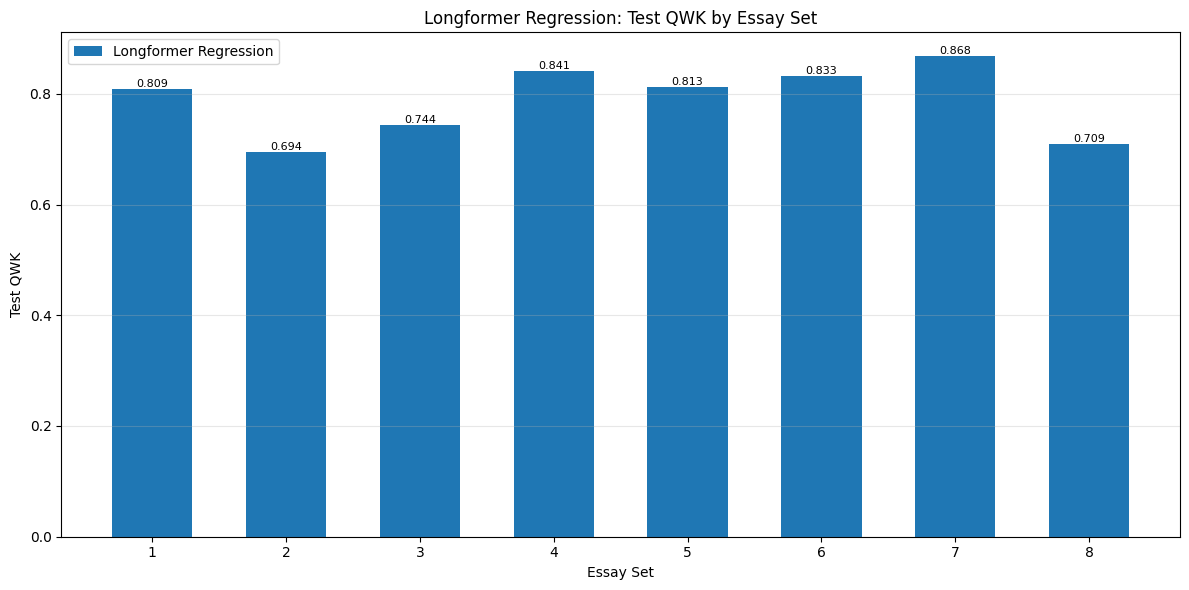

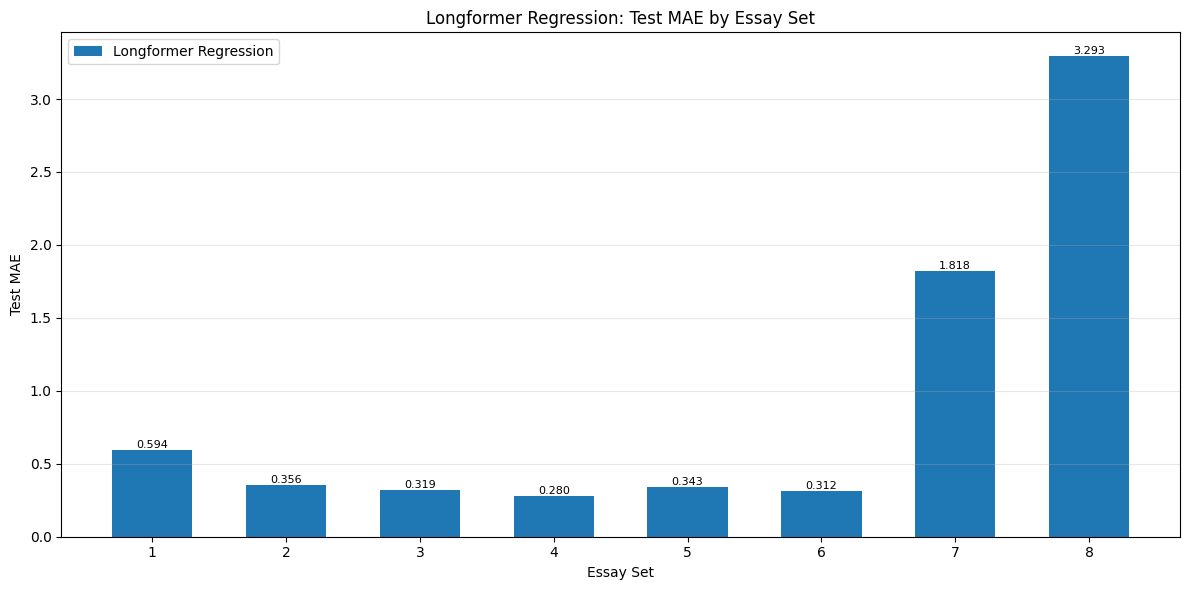

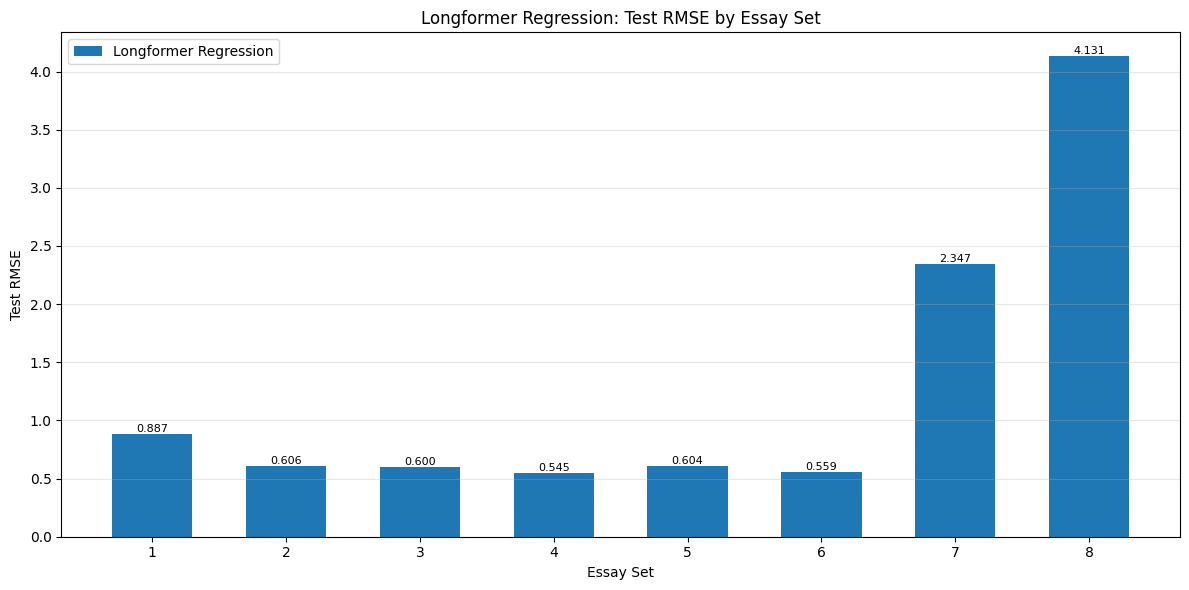


Average summary:


,Method,Avg Test QWK,Avg Test MAE,Avg Test RMSE
8,Longformer Regression,0.7889,0.9142,1.2845


In [13]:
# ============================================================
# Plot Longformer results
# ============================================================

plot_df = final_results_df[
    final_results_df["essay_set"].astype(str) != "average"
].copy()

avg_df = final_results_df[
    final_results_df["essay_set"].astype(str) == "average"
].copy()

plot_df["essay_set"] = plot_df["essay_set"].astype(int)


def plot_single_method_metric_by_essay_set(df, metric_col, ylabel, title):
    essay_sets = sorted(df["essay_set"].unique())
    method_name = df["method"].iloc[0]

    values = df.sort_values("essay_set")[metric_col].values

    x = np.arange(len(essay_sets))

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        x,
        values,
        width=0.6,
        label=method_name,
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.xticks(x, essay_sets)
    plt.xlabel("Essay Set")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_qwk",
    ylabel="Test QWK",
    title="Longformer Regression: Test QWK by Essay Set",
)

plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_mae",
    ylabel="Test MAE",
    title="Longformer Regression: Test MAE by Essay Set",
)

plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_rmse",
    ylabel="Test RMSE",
    title="Longformer Regression: Test RMSE by Essay Set",
)

avg_summary = avg_df[["method", "test_qwk", "test_mae", "test_rmse"]].copy()

avg_summary = avg_summary.rename(columns={
    "method": "Method",
    "test_qwk": "Avg Test QWK",
    "test_mae": "Avg Test MAE",
    "test_rmse": "Avg Test RMSE",
})

avg_summary["Avg Test QWK"] = avg_summary["Avg Test QWK"].astype(float).round(4)
avg_summary["Avg Test MAE"] = avg_summary["Avg Test MAE"].astype(float).round(4)
avg_summary["Avg Test RMSE"] = avg_summary["Avg Test RMSE"].astype(float).round(4)

print("\nAverage summary:")
display(avg_summary)